<a href="https://colab.research.google.com/github/seik345/EstadisticaInferencial2026/blob/main/StudentPerformance/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# student performance

In [4]:
# student_performance

In [5]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/guadalupesbel-commits/EstadisticaVerano2026/refs/heads/main/Studentperformance/Student_Performance.csv")
df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establescamos las horas de estudio (Hours_Studied) como variable dependiente y el indice de desempeño ("Performance_Index") como la variable dependiente. Estpo porque la hipotesis inicial es que cambios en las horas de estudio puedo cambiar cambios en el indice de desempeño, sin embargo cambios en los indices de desempeño no causa cambios en las horas de estudio

In [6]:
X = df["Hours_Studied"]   #Variable independiente
Y = df["Performance_Index"]   #Variable dependiente

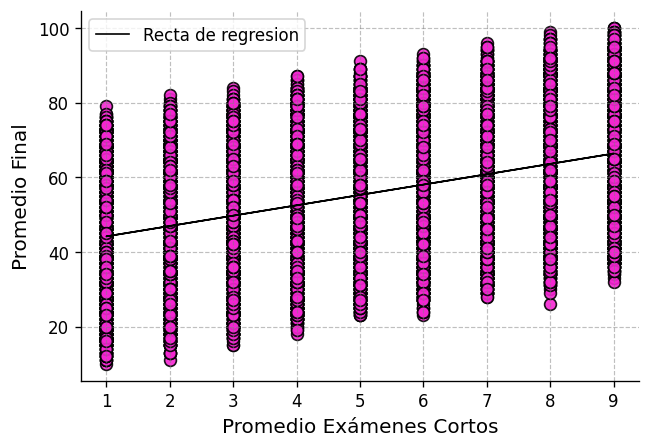

In [12]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50                  # tamaño de los puntos
)

# Ajustamos el modelo de regresión lineal
regressor = LinearRegression()
# X debe ser un array 2D para sklearn
X_reshaped = X.values.reshape(-1, 1)
regressor.fit(X_reshaped, Y)
y_calculada = regressor.predict(X_reshaped)

#Gráfico de la linea
plt.plot(
    X, y_calculada,
    color='black', #color de la linea
    linewidth=1.0,    #grosor de la línea
    label='Recta de regresion'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio Exámenes Cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio Final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

# Mostrar la leyenda para la recta de regresión
plt.legend()

# Mostrar el gráfico
plt.show()

El grafico de dispersion muestra una clara tendencial lineal. Se puede observar que conforme aumenta las horas de estudio $(X)$ aumenta el indice de desempeño $(Y)$. Conlo que se espera un coeficiente de correlacion positivo y parece cumplirse el supuesto de lienalidad  

In [9]:
#Importar la funcion pearsorn desde scipy.status
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.3737
valor_p:  0.0000


El coeficiente de correlacion es $r=0.3$

In [11]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,41.379175
Hours_Studied,2.773063


In [10]:
#Coeficiente de determinacion
from sklearn.metrics import r2_score
r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  13.97%


Una vez ajustado el modelo de regresion lineal, se obtiene un coeficiente de determinacion de $R^2=0.1397$. Entonces teniendo las horas de estudio y el modelo ajustado, solo podemos justificar la variabilidad en las calificaciones en un 13.97%, lo que es muy poco